In [9]:
from sklearn.svm import SVC

# Train the SVM model
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Print training completion
print("\n✅ SVM model trained successfully!")


✅ SVM model trained successfully!


In [13]:
test_image_path = df_sample['image_path'].iloc[0]  # Use the first image from dataset
predict_image_label(test_image_path, svm_model, label_encoder)



🖼️ Predicted label: food


'food'

In [14]:
def predict_image_label(image_path, model, label_encoder):
    """Preprocess an image and predict its label using the trained SVM model."""
    try:
        # Load the image using PIL
        img = Image.open(image_path).convert('RGB')  # Convert to RGB
        img = img.resize(IMG_SIZE)  # Resize to match training data

        # Convert to NumPy array and flatten
        img_array = np.array(img).flatten().astype(np.float16)
        img_array = img_array.reshape(1, -1)  # Reshape for SVM

        # Make prediction
        predicted_label_index = model.predict(img_array)[0]
        predicted_label = label_encoder.inverse_transform([predicted_label_index])[0]

        print(f"\n🖼️ Predicted label: {predicted_label}")
        return predicted_label

    except Exception as e:
        print(f"❌ Error processing image {image_path}: {e}")
        return None

# Example Usage
test_image_path = "D:\\College\\Term3\\computervision\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\example.jpg"  # Change to actual path
predict_image_label(test_image_path, svm_model, label_encoder)


❌ Error processing image D:\College\Term3\computervision\Yelp-Photos\Yelp Photos\yelp_photos\photos\example.jpg: [Errno 2] No such file or directory: 'D:\\College\\Term3\\computervision\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\example.jpg'


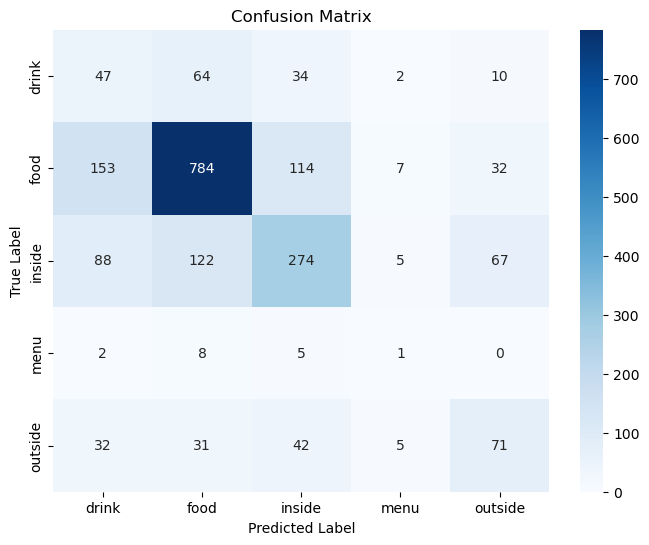


🔍 Classification Report:
              precision    recall  f1-score   support

       drink       0.15      0.30      0.20       157
        food       0.78      0.72      0.75      1090
      inside       0.58      0.49      0.53       556
        menu       0.05      0.06      0.06        16
     outside       0.39      0.39      0.39       181

    accuracy                           0.59      2000
   macro avg       0.39      0.39      0.39      2000
weighted avg       0.63      0.59      0.61      2000



In [16]:
# Make predictions
y_pred = svm_model.predict(X_test)
y_pred_proba = svm_model.predict_proba(X_test)

# Generate Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Print Classification Report
print("\n🔍 Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Compute additional evaluation metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print evaluation metrics
print(f"\n📊 Model Performance Metrics:")
print(f"🔹 Precision: {precision:.4f}")
print(f"🔹 Recall: {recall:.4f}")
print(f"🔹 F1-score: {f1:.4f}")



📊 Model Performance Metrics:
🔹 Precision: 0.6334
🔹 Recall: 0.5885
🔹 F1-score: 0.6072


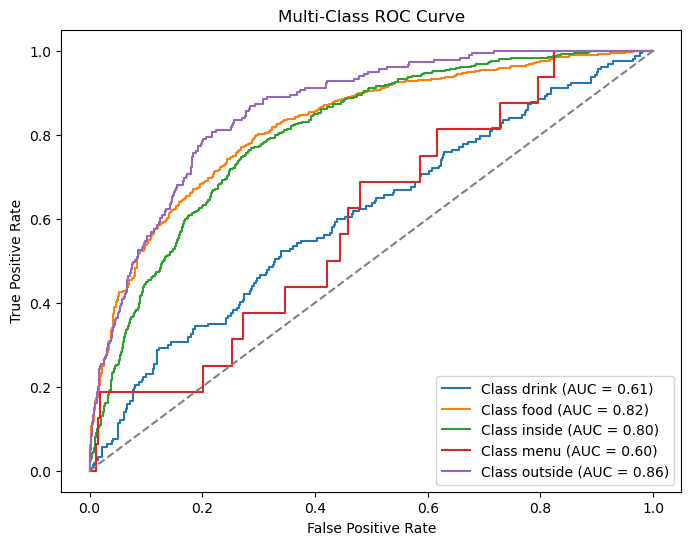

In [18]:
from sklearn.preprocessing import label_binarize

# Binarize labels for multi-class AUC computation
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_pred_proba = svm_model.predict_proba(X_test)

# Compute ROC Curve & AUC for each class
plt.figure(figsize=(8, 6))
for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {label_encoder.classes_[i]} (AUC = {auc_score:.2f})')

# Plot adjustments
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()


In [1]:
!jupyter nbconvert --to html Tirth_Mayisha_SVM.ipynb

[NbConvertApp] Converting notebook Tirth_Mayisha_SVM.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 432806 bytes to Tirth_Mayisha_SVM.html


PROMPT:
Build an SVM models to predict the label of an image from a given image on the yelp Photos dataset
